In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Importamos la base de datos que fue trabajada anteriormente

focos_semanales = pd.read_parquet("data/processed/firms_open_meteo_weekly/open_meteo_firms_weekly_history.parquet")

focos_semanales.shape

(8911, 32)

In [5]:
focos_semanales.head()

,departamento,departamento_iso,fecha_inicio_semana,fecha_fin_semana,anio,numero_semana,n_dias_esperados,n_dias_observados,cobertura_temporal_pct,cobertura_espacial_min_pct,...,precipitation_max_daily_weekly,et0_fao_evapotranspiration_sum_weekly,et0_fao_evapotranspiration_max_daily_weekly,wind_direction_10m_resultant_length_spatial_daily_mean_weekly,wind_direction_10m_dominant_circular_mean_weekly,wind_direction_10m_resultant_length_weekly,cantidad_detecciones,nivel_actividad_firms,nivel_actividad_firms_codigo,target_firms_disponible
0,Artigas,UY-AR,2017-01-02,2017-01-08,2017,1,7,7,100.0,100.0,...,7.192857,33.165714,6.92,0.989593,54.172101,0.678583,<NA>,NaN,<NA>,False
1,Artigas,UY-AR,2017-01-09,2017-01-15,2017,2,7,7,100.0,100.0,...,33.128571,35.366429,6.89,0.987310,76.036628,0.681346,<NA>,NaN,<NA>,False
2,Artigas,UY-AR,2017-01-16,2017-01-22,2017,3,7,7,100.0,100.0,...,30.085714,41.072143,7.21,0.994570,106.704465,0.448703,<NA>,NaN,<NA>,False
3,Artigas,UY-AR,2017-01-23,2017-01-29,2017,4,7,7,100.0,100.0,...,5.078571,40.637143,7.05,0.987591,109.125519,0.460331,<NA>,NaN,<NA>,False
4,Artigas,UY-AR,2017-01-30,2017-02-05,2017,5,7,7,100.0,100.0,...,30.721429,36.067143,6.82,0.996177,67.483165,0.360955,<NA>,NaN,<NA>,False


In [6]:
focos_semanales.columns

Index(['departamento', 'departamento_iso', 'fecha_inicio_semana',
       'fecha_fin_semana', 'anio', 'numero_semana', 'n_dias_esperados',
       'n_dias_observados', 'cobertura_temporal_pct',
       'cobertura_espacial_min_pct', 'precipitation_days_weekly',
       'temperature_2m_max_mean_weekly', 'temperature_2m_max_weekly',
       'temperature_2m_min_mean_weekly', 'temperature_2m_min_weekly',
       'relative_humidity_2m_min_mean_weekly',
       'relative_humidity_2m_min_weekly',
       'relative_humidity_2m_max_mean_weekly',
       'relative_humidity_2m_max_weekly', 'wind_speed_10m_max_mean_weekly',
       'wind_speed_10m_max_weekly', 'precipitation_sum_weekly',
       'precipitation_max_daily_weekly',
       'et0_fao_evapotranspiration_sum_weekly',
       'et0_fao_evapotranspiration_max_daily_weekly',
       'wind_direction_10m_resultant_length_spatial_daily_mean_weekly',
       'wind_direction_10m_dominant_circular_mean_weekly',
       'wind_direction_10m_resultant_length_weekly',

In [7]:
#Ordenamos nuestros datos en funcion de la fecha inicial de cada semana
focos_semanales = focos_semanales.sort_values(["departamento", "fecha_inicio_semana"])

In [8]:
#Verificamos la variable objetivo para saber la cantidad de valores que tenemos de la misma
focos_semanales["target_firms_disponible"].value_counts()

target_firms_disponible
True     7923
False     988
Name: count, dtype: int64

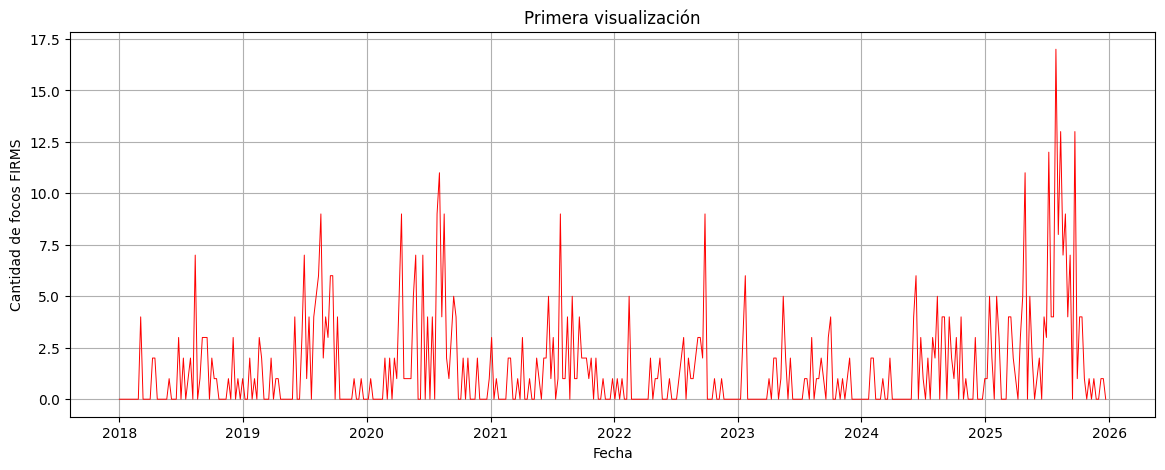

In [9]:
#Generamos una grafica para poder visualizar la cantidad de focos por departemento o en el uruguay a lo largo de los años disponibles

departemanto_seleccionado = focos_semanales[focos_semanales["departamento"] == "Artigas"]

plt.figure(figsize=(14, 5))

plt.plot(
    departemanto_seleccionado["fecha_inicio_semana"],
    departemanto_seleccionado["cantidad_detecciones"],
    linewidth=0.7,
    color="red"
)

plt.title("Primera visualización")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de focos FIRMS")
plt.grid(True)

plt.show()

In [10]:
# Desplazamos la precipitación una semana dentro de cada departamento.
# De esta forma, cada semana t queda asociada con la precipitación de t-1,
# evitando utilizar meteorología de la propia semana objetivo.
focos_semanales["precipitation_lag1"] = (
    focos_semanales
    .groupby("departamento")["precipitation_sum_weekly"]
    .shift(1)
)

In [11]:
#En esta visualizacion se puede ver como los datos de precipitacion fueron desplazados un espacio por eso el primer valor de 2017-01 quedo NaN porque no hay un dia anterior
focos_semanales[[
    "departamento",
    "fecha_inicio_semana",
    "precipitation_sum_weekly",
    "precipitation_lag1"
]].head(10)

,departamento,fecha_inicio_semana,precipitation_sum_weekly,precipitation_lag1
0,Artigas,2017-01-02,16.414286,NaN
1,Artigas,2017-01-09,67.992857,16.414286
2,Artigas,2017-01-16,30.600000,67.992857
3,Artigas,2017-01-23,5.278571,30.600000
4,Artigas,2017-01-30,47.535714,5.278571
5,Artigas,2017-02-06,50.157143,47.535714
6,Artigas,2017-02-13,50.457143,50.157143
7,Artigas,2017-02-20,14.014286,50.457143
8,Artigas,2017-02-27,11.121429,14.014286
9,Artigas,2017-03-06,100.050000,11.121429


Generamos los lags para cada variable meteorologica

In [12]:
# Variables meteorológicas que queremos desplazar una semana
variables_lag = [
    "precipitation_sum_weekly",
    "temperature_2m_max_mean_weekly",
    "temperature_2m_min_mean_weekly",
    "relative_humidity_2m_min_mean_weekly",
    "wind_speed_10m_max_mean_weekly",
    "et0_fao_evapotranspiration_sum_weekly"
]

# Generamos lag1 dentro de cada departamento
for variable in variables_lag:
    focos_semanales[f"{variable}_lag1"] = (
        focos_semanales
        .groupby("departamento")[variable]
        .shift(1)
    )

In [13]:
#En esta visualizacion se puede ver como todos los datos fueron desplazados un espacio por eso el primer valor de 2017-01 quedo NaN porque no hay un dia anterior
focos_semanales[[
    "departamento",
    "fecha_inicio_semana",
    "precipitation_sum_weekly_lag1",
    "temperature_2m_max_mean_weekly_lag1",
    "temperature_2m_min_mean_weekly_lag1",
    "relative_humidity_2m_min_mean_weekly_lag1",
    "wind_speed_10m_max_mean_weekly_lag1",
    "et0_fao_evapotranspiration_sum_weekly_lag1"
    
]].head(10)

,departamento,fecha_inicio_semana,precipitation_sum_weekly_lag1,temperature_2m_max_mean_weekly_lag1,temperature_2m_min_mean_weekly_lag1,relative_humidity_2m_min_mean_weekly_lag1,wind_speed_10m_max_mean_weekly_lag1,et0_fao_evapotranspiration_sum_weekly_lag1
0,Artigas,2017-01-02,NaN,NaN,NaN,NaN,NaN,NaN
1,Artigas,2017-01-09,16.414286,30.098980,22.496939,61.183673,5.682143,33.165714
2,Artigas,2017-01-16,67.992857,30.717347,21.640816,58.153061,5.038469,35.366429
3,Artigas,2017-01-23,30.600000,29.448980,19.744898,50.255102,5.390816,41.072143
4,Artigas,2017-01-30,5.278571,28.085714,18.137755,44.969388,5.106429,40.637143
5,Artigas,2017-02-06,47.535714,30.067347,21.218367,53.255102,4.849388,36.067143
6,Artigas,2017-02-13,50.157143,27.200000,18.500000,57.428571,4.777755,30.431429
7,Artigas,2017-02-20,50.457143,28.918367,20.803061,65.214286,4.847857,26.952143
8,Artigas,2017-02-27,14.014286,30.847959,22.124490,60.071429,3.332959,33.373571
9,Artigas,2017-03-06,11.121429,29.679592,21.486735,58.336735,4.732755,31.272143


Utilizamos Rolling para tener de 2 a 4 lags anteriores de cada semana es decir a la primera semana se le asigna la semana anterior y asi hasta la cuarta 

In [14]:
# Variables cuyo contexto previo resumimos con MEDIA
variables_media = [
    "temperature_2m_max_mean_weekly_lag1",
    "temperature_2m_min_mean_weekly_lag1",
    "relative_humidity_2m_min_mean_weekly_lag1",
    "wind_speed_10m_max_mean_weekly_lag1"
]

for variable in variables_media:
    nombre_base = variable.replace("_lag1", "")

    focos_semanales[f"{nombre_base}_prev_2w_mean"] = (
        focos_semanales
        .groupby("departamento")[variable]
        .transform(
            lambda x: x.rolling(window=2, min_periods=2).mean()
        )
    )

    focos_semanales[f"{nombre_base}_prev_4w_mean"] = (
        focos_semanales
        .groupby("departamento")[variable]
        .transform(
            lambda x: x.rolling(window=4, min_periods=4).mean()
        )
    )

In [15]:
# Variables cuyo contexto previo resumimos con MEDIA
variables_suma = [
    "precipitation_sum_weekly_lag1",
    "et0_fao_evapotranspiration_sum_weekly_lag1"
]

for variable in variables_suma:
    nombre_base = variable.replace("_lag1", "")

    focos_semanales[f"{nombre_base}_prev_2w_sum"] = (
        focos_semanales
        .groupby("departamento")[variable]
        .transform(
            lambda x: x.rolling(window=2, min_periods=2).sum()
        )
    )

    focos_semanales[f"{nombre_base}_prev_4w_sum"] = (
        focos_semanales
        .groupby("departamento")[variable]
        .transform(
            lambda x: x.rolling(window=4, min_periods=4).sum()
        )
    )

In [16]:
focos_semanales[
    focos_semanales["departamento"] == "Artigas"
][[
    "fecha_inicio_semana",
    "precipitation_sum_weekly",
    "precipitation_sum_weekly_lag1",
    "precipitation_sum_weekly_prev_2w_sum",
    "precipitation_sum_weekly_prev_4w_sum"
]].head(10)

,fecha_inicio_semana,precipitation_sum_weekly,precipitation_sum_weekly_lag1,precipitation_sum_weekly_prev_2w_sum,precipitation_sum_weekly_prev_4w_sum
0,2017-01-02,16.414286,NaN,NaN,NaN
1,2017-01-09,67.992857,16.414286,NaN,NaN
2,2017-01-16,30.600000,67.992857,84.407143,NaN
3,2017-01-23,5.278571,30.600000,98.592857,NaN
4,2017-01-30,47.535714,5.278571,35.878571,120.285714
5,2017-02-06,50.157143,47.535714,52.814286,151.407143
6,2017-02-13,50.457143,50.157143,97.692857,133.571429
7,2017-02-20,14.014286,50.457143,100.614286,153.428571
8,2017-02-27,11.121429,14.014286,64.471429,162.164286
9,2017-03-06,100.050000,11.121429,25.135714,125.750000


In [ ]:
#Creamos las variables historicas FIRMS usando solamente semanas anteriores
focos_semanales["cantidad_detecciones_hist_lag1"] = (
    focos_semanales
    .groupby("departamento")["cantidad_detecciones_hist"]
    .shift(1)
)

focos_semanales["detecciones_prev_2w_sum"] = (
    focos_semanales
    .groupby("departamento")["cantidad_detecciones_hist_lag1"]
    .transform(lambda x: x.rolling(window=2, min_periods=2).sum())
)

focos_semanales["detecciones_prev_4w_sum"] = (
    focos_semanales
    .groupby("departamento")["cantidad_detecciones_hist_lag1"]
    .transform(lambda x: x.rolling(window=4, min_periods=4).sum())
)

focos_semanales["semanas_con_deteccion_prev_4w"] = (
    focos_semanales
    .groupby("departamento")["cantidad_detecciones_hist_lag1"]
    .transform(lambda x: x.gt(0).where(x.notna()).rolling(window=4, min_periods=4).sum())
)

In [ ]:
#Verificamos las variables FIRMS historicas para un departamento
ejemplo_artigas = focos_semanales[
    focos_semanales["departamento"] == "Artigas"
].copy()

assert ejemplo_artigas["cantidad_detecciones_hist_lag1"].equals(
    ejemplo_artigas["cantidad_detecciones_hist"].shift(1)
)
assert ejemplo_artigas["detecciones_prev_2w_sum"].equals(
    ejemplo_artigas["cantidad_detecciones_hist"].shift(1).rolling(2, min_periods=2).sum()
)
assert ejemplo_artigas["detecciones_prev_4w_sum"].equals(
    ejemplo_artigas["cantidad_detecciones_hist"].shift(1).rolling(4, min_periods=4).sum()
)
assert ejemplo_artigas["semanas_con_deteccion_prev_4w"].equals(
    ejemplo_artigas["cantidad_detecciones_hist"].shift(1).gt(0)
    .where(ejemplo_artigas["cantidad_detecciones_hist"].shift(1).notna())
    .rolling(4, min_periods=4).sum()
)

ejemplo_artigas[
    ejemplo_artigas["fecha_inicio_semana"].between("2017-12-04", "2018-01-08")
][[
    "fecha_inicio_semana",
    "cantidad_detecciones_hist",
    "cantidad_detecciones_hist_lag1",
    "detecciones_prev_2w_sum",
    "detecciones_prev_4w_sum",
    "semanas_con_deteccion_prev_4w"
]]

In [17]:
#Eliminamos los datos de 2017 ya que ya creamos las ventanas correspondientes para 2018
datos_modelo = focos_semanales[
    focos_semanales["target_firms_disponible"] == True
].copy()

datos_modelo.shape

(7923, 51)

In [18]:
features = [
    # Semana anterior
    "precipitation_sum_weekly_lag1",
    "temperature_2m_max_mean_weekly_lag1",
    "temperature_2m_min_mean_weekly_lag1",
    "relative_humidity_2m_min_mean_weekly_lag1",
    "wind_speed_10m_max_mean_weekly_lag1",
    "et0_fao_evapotranspiration_sum_weekly_lag1",

    # Últimas 2 semanas
    "precipitation_sum_weekly_prev_2w_sum",
    "temperature_2m_max_mean_weekly_prev_2w_mean",
    "temperature_2m_min_mean_weekly_prev_2w_mean",
    "relative_humidity_2m_min_mean_weekly_prev_2w_mean",
    "wind_speed_10m_max_mean_weekly_prev_2w_mean",
    "et0_fao_evapotranspiration_sum_weekly_prev_2w_sum",

    # Últimas 4 semanas
    "precipitation_sum_weekly_prev_4w_sum",
    "temperature_2m_max_mean_weekly_prev_4w_mean",
    "temperature_2m_min_mean_weekly_prev_4w_mean",
    "relative_humidity_2m_min_mean_weekly_prev_4w_mean",
    "wind_speed_10m_max_mean_weekly_prev_4w_mean",
    "et0_fao_evapotranspiration_sum_weekly_prev_4w_sum",

    # Actividad FIRMS de semanas anteriores
    "cantidad_detecciones_hist_lag1",
    "detecciones_prev_2w_sum",
    "detecciones_prev_4w_sum",
    "semanas_con_deteccion_prev_4w"
]

In [19]:
datos_modelo[features].isnull().sum()

precipitation_sum_weekly_lag1                        0
temperature_2m_max_mean_weekly_lag1                  0
temperature_2m_min_mean_weekly_lag1                  0
relative_humidity_2m_min_mean_weekly_lag1            0
wind_speed_10m_max_mean_weekly_lag1                  0
et0_fao_evapotranspiration_sum_weekly_lag1           0
precipitation_sum_weekly_prev_2w_sum                 0
temperature_2m_max_mean_weekly_prev_2w_mean          0
temperature_2m_min_mean_weekly_prev_2w_mean          0
relative_humidity_2m_min_mean_weekly_prev_2w_mean    0
wind_speed_10m_max_mean_weekly_prev_2w_mean          0
et0_fao_evapotranspiration_sum_weekly_prev_2w_sum    0
precipitation_sum_weekly_prev_4w_sum                 0
temperature_2m_max_mean_weekly_prev_4w_mean          0
temperature_2m_min_mean_weekly_prev_4w_mean          0
relative_humidity_2m_min_mean_weekly_prev_4w_mean    0
wind_speed_10m_max_mean_weekly_prev_4w_mean          0
et0_fao_evapotranspiration_sum_weekly_prev_4w_sum    0
dtype: int

In [20]:
#Aca podemos observar que para cada departamenteo existen los datos correctos en la misma semana
datos_modelo[
    datos_modelo["fecha_inicio_semana"] == "2018-01-01"
][
    ["departamento", "fecha_inicio_semana"]
    + features
    + ["nivel_actividad_firms"]
].head(19)

,departamento,fecha_inicio_semana,precipitation_sum_weekly_lag1,temperature_2m_max_mean_weekly_lag1,temperature_2m_min_mean_weekly_lag1,relative_humidity_2m_min_mean_weekly_lag1,wind_speed_10m_max_mean_weekly_lag1,et0_fao_evapotranspiration_sum_weekly_lag1,precipitation_sum_weekly_prev_2w_sum,temperature_2m_max_mean_weekly_prev_2w_mean,...,relative_humidity_2m_min_mean_weekly_prev_2w_mean,wind_speed_10m_max_mean_weekly_prev_2w_mean,et0_fao_evapotranspiration_sum_weekly_prev_2w_sum,precipitation_sum_weekly_prev_4w_sum,temperature_2m_max_mean_weekly_prev_4w_mean,temperature_2m_min_mean_weekly_prev_4w_mean,relative_humidity_2m_min_mean_weekly_prev_4w_mean,wind_speed_10m_max_mean_weekly_prev_4w_mean,et0_fao_evapotranspiration_sum_weekly_prev_4w_sum,nivel_actividad_firms
52,Artigas,2018-01-01,15.264286,31.971429,20.313265,36.408163,4.487653,45.945000,27.278571,30.948980,...,40.530612,5.253878,90.899286,40.357143,30.885714,19.261224,37.609694,5.682832,187.588571,Sin detección
521,Canelones,2018-01-01,4.033333,30.190476,18.895238,40.000000,4.946190,45.063333,20.733333,27.714286,...,45.119048,5.254762,80.556667,62.200000,28.028571,17.072619,41.309524,5.731071,166.336667,Alto
990,Cerro Largo,2018-01-01,7.964286,31.693878,18.337755,32.000000,4.919082,46.857143,14.400000,29.376531,...,38.994898,5.447500,83.830714,24.550000,29.007143,17.342092,38.941327,5.705179,165.159286,Bajo
1459,Colonia,2018-01-01,4.614286,31.932653,19.975510,33.755102,4.828776,47.614286,14.542857,29.057143,...,39.071429,5.090000,83.398571,38.757143,29.405612,18.093367,37.030612,5.547296,175.905714,Bajo
1928,Durazno,2018-01-01,13.783333,31.909524,19.542857,33.797619,4.678214,47.227500,25.041667,29.644643,...,39.684524,5.432381,86.716667,42.816667,29.728274,17.700298,36.092262,5.832202,177.507500,Bajo
2397,Flores,2018-01-01,7.040000,32.111429,19.140000,32.342857,4.381429,47.352000,17.320000,29.317143,...,38.914286,4.941286,84.236000,43.840000,29.617857,17.242143,35.128571,5.415000,175.336000,Sin detección
2866,Florida,2018-01-01,5.930000,31.047143,18.502857,36.242857,4.440714,45.823000,19.670000,28.596429,...,41.514286,5.082786,82.551000,43.080000,28.887143,16.835357,37.285714,5.560286,171.288000,Moderado
3335,Lavalleja,2018-01-01,3.941667,30.497619,17.980952,37.845238,4.355476,43.809167,10.216667,28.117262,...,42.845238,4.905119,79.146667,23.433333,28.108631,16.402976,40.431548,5.446429,162.179167,Alto
3804,Maldonado,2018-01-01,0.066667,28.161905,18.847619,48.809524,5.530476,42.856667,7.966667,26.009524,...,51.214286,5.963810,77.920000,33.166667,25.864286,16.996429,50.464286,6.402738,156.716667,Alto
4273,Montevideo,2018-01-01,0.400000,28.671429,19.685714,47.714286,5.905714,45.040000,12.200000,26.350000,...,50.642857,6.082143,81.130000,53.200000,26.425000,17.839286,48.678571,6.432143,163.900000,Sin detección


Observamos la distribucion de las clases en el dataset

In [21]:
orden_clases = [
    "Sin detección",
    "Bajo",
    "Moderado",
    "Alto"
]

distribucion_anual = pd.crosstab(
    datos_modelo["anio"],
    datos_modelo["nivel_actividad_firms"]
)

# Ordenamos las columnas
distribucion_anual = distribucion_anual[orden_clases]

distribucion_anual

nivel_actividad_firms,Sin detección,Bajo,Moderado,Alto
anio,,,,
2018,653,132,149,73
2019,568,175,150,95
2020,520,159,142,167
2021,643,162,110,73
2022,617,160,130,81
2023,615,170,135,68
2024,738,128,102,39
2025,613,151,116,89


In [22]:
distribucion_anual_pct = pd.crosstab(
    datos_modelo["anio"],
    datos_modelo["nivel_actividad_firms"],
    normalize="index"
) * 100

distribucion_anual_pct = distribucion_anual_pct[orden_clases]

distribucion_anual_pct.round(2)

nivel_actividad_firms,Sin detección,Bajo,Moderado,Alto
anio,,,,
2018,64.85,13.11,14.80,7.25
2019,57.49,17.71,15.18,9.62
2020,52.63,16.09,14.37,16.90
2021,65.08,16.40,11.13,7.39
2022,62.45,16.19,13.16,8.20
2023,62.25,17.21,13.66,6.88
2024,73.29,12.71,10.13,3.87
2025,63.26,15.58,11.97,9.18


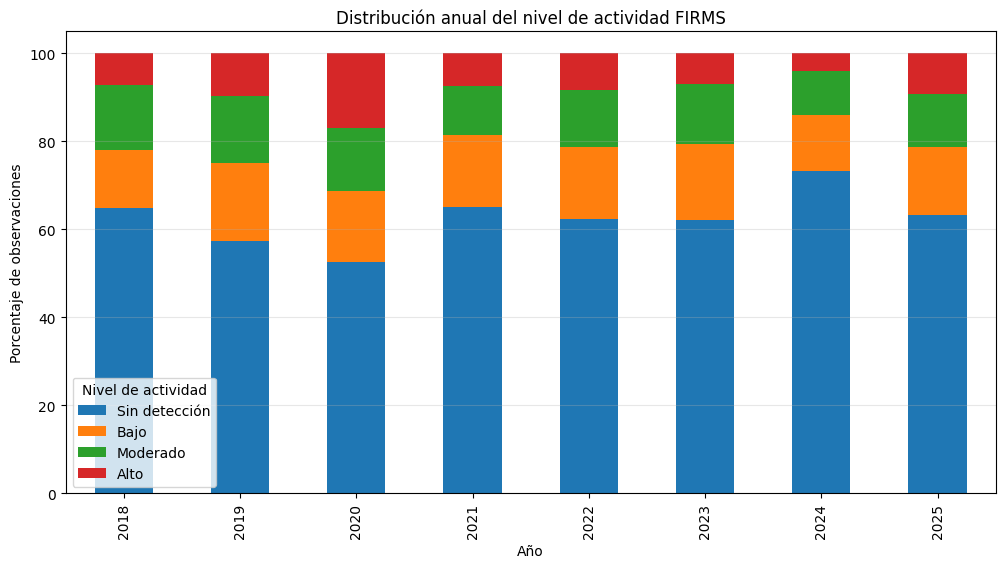

In [23]:
distribucion_anual_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribución anual del nivel de actividad FIRMS")
plt.xlabel("Año")
plt.ylabel("Porcentaje de observaciones")
plt.legend(title="Nivel de actividad")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [42]:
datos_modelo.drop(columns=[
    "cantidad_detecciones_hist",
    "nivel_actividad_firms_hist",
    "nivel_actividad_firms_codigo_hist"
]).to_parquet(
    "data/processed/modelado/dataset_supervisado_con_lags_firms.parquet",
    index=False
)